### Importing the libraries

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Load Data

In [55]:
df = pd.read_csv('Data.csv')
df.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


### Info Data

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54170 entries, 0 to 54169
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   DateTime       54170 non-null  object
 1   Consumption    54170 non-null  int64 
 2   Production     54170 non-null  int64 
 3   Nuclear        54170 non-null  int64 
 4   Wind           54170 non-null  int64 
 5   Hydroelectric  54170 non-null  int64 
 6   Oil and Gas    54170 non-null  int64 
 7   Coal           54170 non-null  int64 
 8   Solar          54170 non-null  int64 
 9   Biomass        54170 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 4.1+ MB


### Check the null Data

In [57]:
def CheckNullValues(Data):
    null_values = Data.isnull().sum().sum()
    if null_values > 0:
        print("There are null values in the dataset")
    else:
        print("There are no null values in the dataset")
        
CheckNullValues(df)

There are no null values in the dataset


### Check the Duplicated Data

In [58]:
def CheckDuplicated(Data):
    num_dup = Data.duplicated().sum()
    if num_dup > 0:
        print("Numer of deplicated is : ", num_dup)
        Data.drop_duplicates(inplace=True)
        print("Number of deplicated after drop is : ", Data.duplicated().sum())
    else:
        print("No duplicated values")

CheckDuplicated(df)

Numer of deplicated is :  4
Number of deplicated after drop is :  0


### Convert Date to datetime

In [59]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54166 entries, 0 to 54169
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   DateTime       54166 non-null  datetime64[ns]
 1   Consumption    54166 non-null  int64         
 2   Production     54166 non-null  int64         
 3   Nuclear        54166 non-null  int64         
 4   Wind           54166 non-null  int64         
 5   Hydroelectric  54166 non-null  int64         
 6   Oil and Gas    54166 non-null  int64         
 7   Coal           54166 non-null  int64         
 8   Solar          54166 non-null  int64         
 9   Biomass        54166 non-null  int64         
dtypes: datetime64[ns](1), int64(9)
memory usage: 4.5 MB


### Sorl Values :

In [60]:
df = df.sort_values('DateTime')

### Extract Day and Month and Year and hour from Date

In [61]:
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour

df.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,Year,Month,Day,Hour
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30,2019,1,1,0
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30,2019,1,1,1
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30,2019,1,1,2
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30,2019,1,1,3
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30,2019,1,1,4


### Average consumption per day / per hour

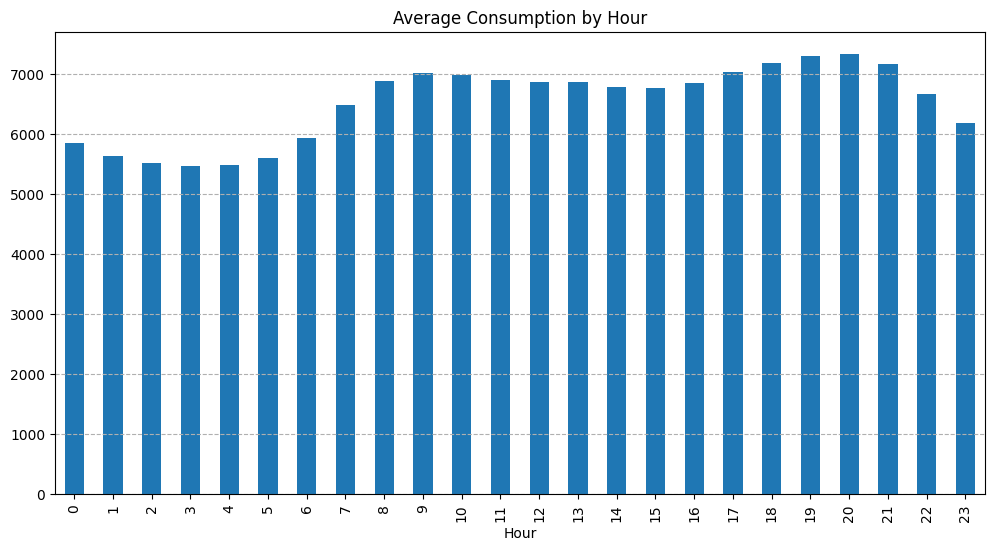

In [62]:
df1 = df[['Consumption','Hour']]
avg_hour = df1.groupby('Hour')['Consumption'].mean()
plt.figure(figsize=(12,6))
plt.title('Average Consumption by Hour')
avg_hour.plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=1)
plt.show()

### Peak consumption hour :

In [63]:
Pick_hour = avg_hour.idxmax()
print(f"Pick Hour : {Pick_hour}")

Pick Hour : 20


### Comparison of total production vs consumption :

In [64]:
sum_prod = df['Production'].sum()
print(f"Sum of Production : {sum_prod}")
sum_cons = df['Consumption'].sum()
print(f"Sum of Consumption : {sum_cons}") 

if sum_prod > sum_cons:
    print("Production is greater than Consumption")
else:
    print("Consumption is greater than Production")


Sum of Production : 345593952
Sum of Consumption : 353518278
Consumption is greater than Production


Text(0.5, 1.0, 'Production et consommation By hour')

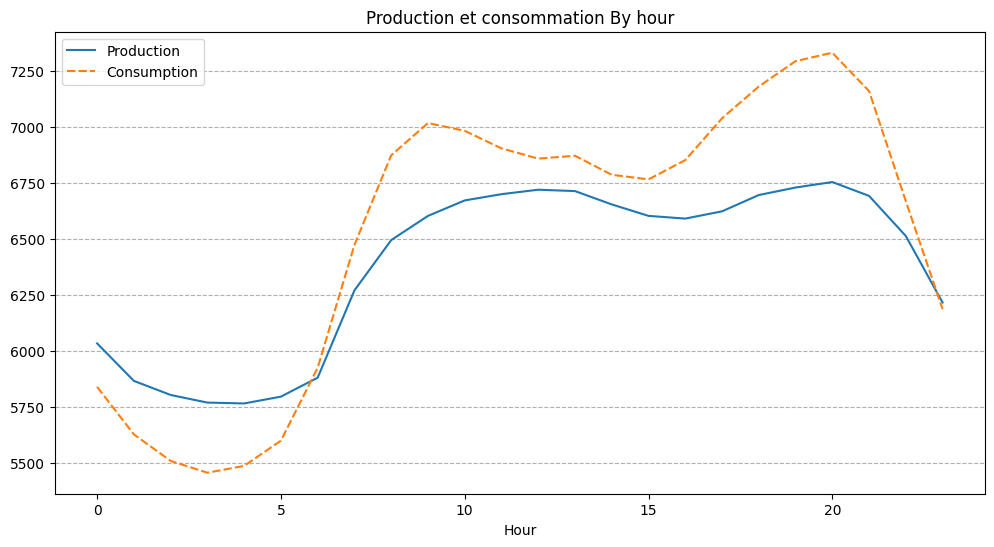

In [65]:
df2 = df[['Production','Consumption','Hour']]
avg = df2.groupby('Hour').mean()
plt.figure(figsize=(12,6))
sns.lineplot(avg)
plt.grid(axis='y', linestyle='--', alpha=1)
plt.title('Production et consommation By hour')

### Average contribution of each energy source :

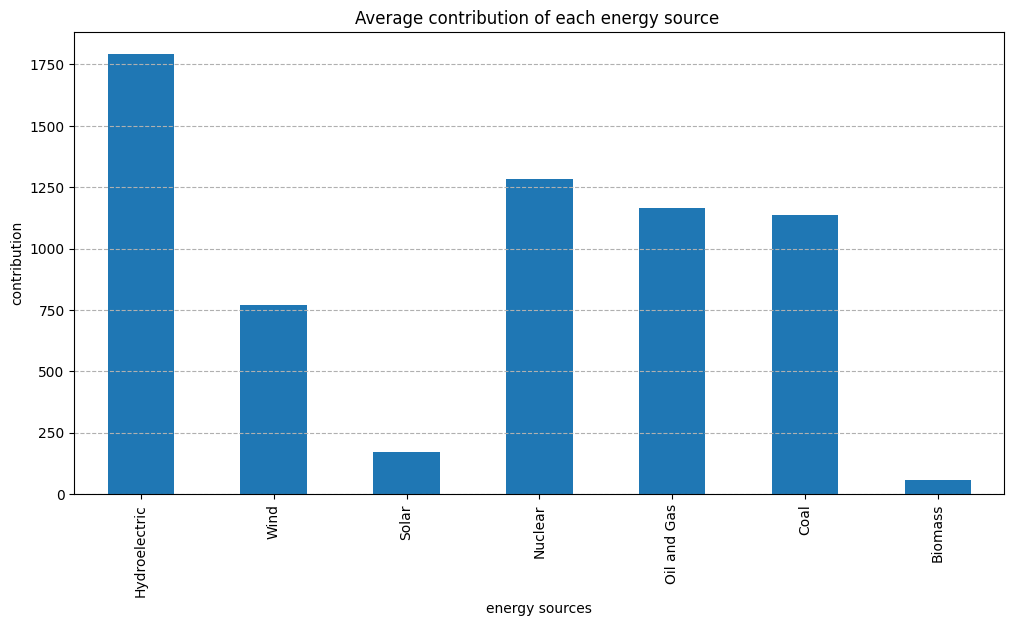

In [66]:
df3 = df[['Hydroelectric', 'Wind', 'Solar', 'Nuclear', 'Oil and Gas', 'Coal', 'Biomass']]
avg_source = df3.mean()
avg_source.plot(kind='bar', figsize=(12, 6))
plt.title('Average contribution of each energy source ')
plt.xlabel('energy sources')
plt.ylabel('contribution')
plt.grid(axis='y', linestyle='--', alpha=1)
plt.show()

### Detection of hours when production is insufficient

<Axes: xlabel='Hour'>

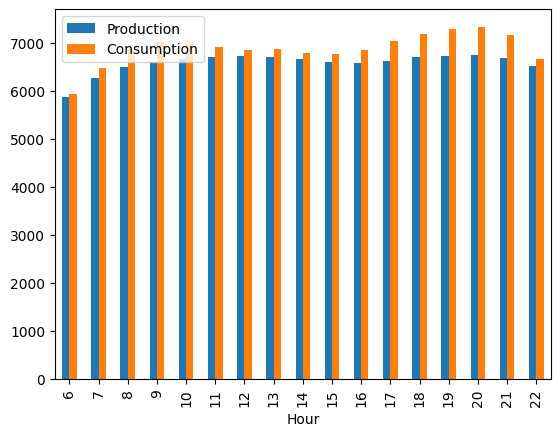

In [72]:
df4 = df[['Production','Consumption','Hour']]
avg_prod_cons = df4.groupby('Hour').mean()
avg_prod_cons_2 = avg_prod_cons.groupby('Hour').filter(lambda x: x['Production'] < x['Consumption'])
avg_prod_cons_2.plot(kind='bar')

### Analysis of correlations (Production vs sources) :

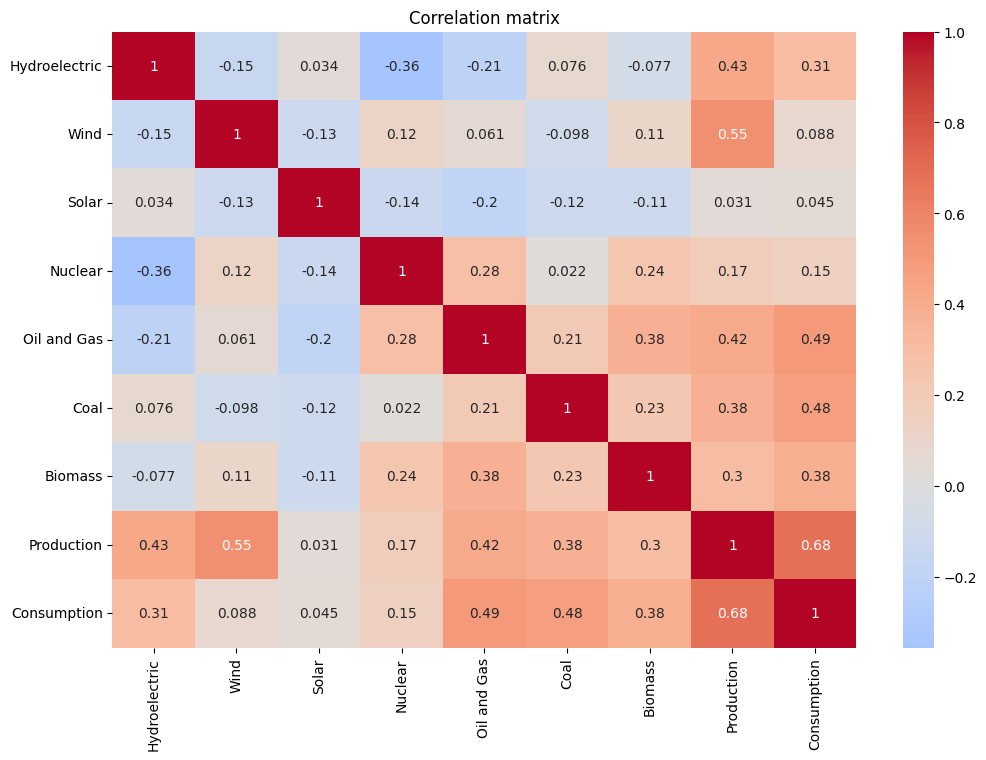

In [68]:
correlation_matrix = df[['Hydroelectric', 'Wind', 'Solar', 'Nuclear', 'Oil and Gas', 'Coal', 'Biomass','Production','Consumption']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()


### Average Production and Consumption by Day, Hour, Month, Year :

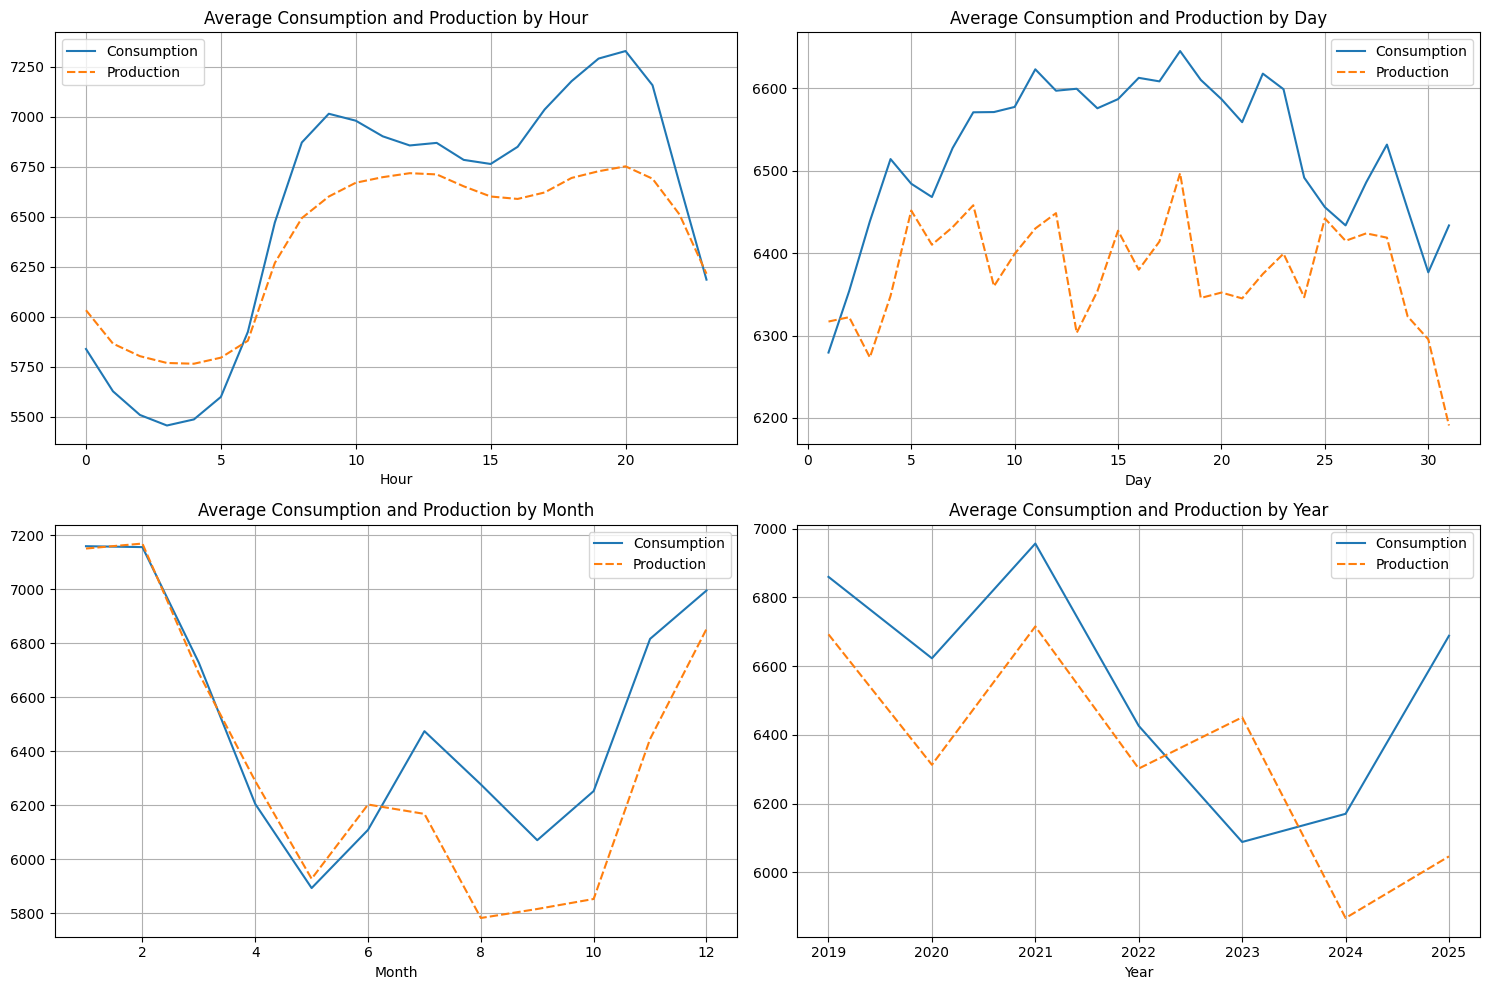

In [69]:
Time_Columns = ['Hour', 'Day', 'Month', 'Year']

plt.figure(figsize=(15, 10))
for i, col in enumerate(Time_Columns):
    plt.subplot(2, 2, i + 1)
    avg = df.groupby(col)[['Consumption', 'Production']].mean()
    sns.lineplot(data=avg)
    plt.title(f'Average Consumption and Production by {col}')
    plt.grid(True)

plt.tight_layout()
plt.show()

### Identification of seasonality Sources (daily)

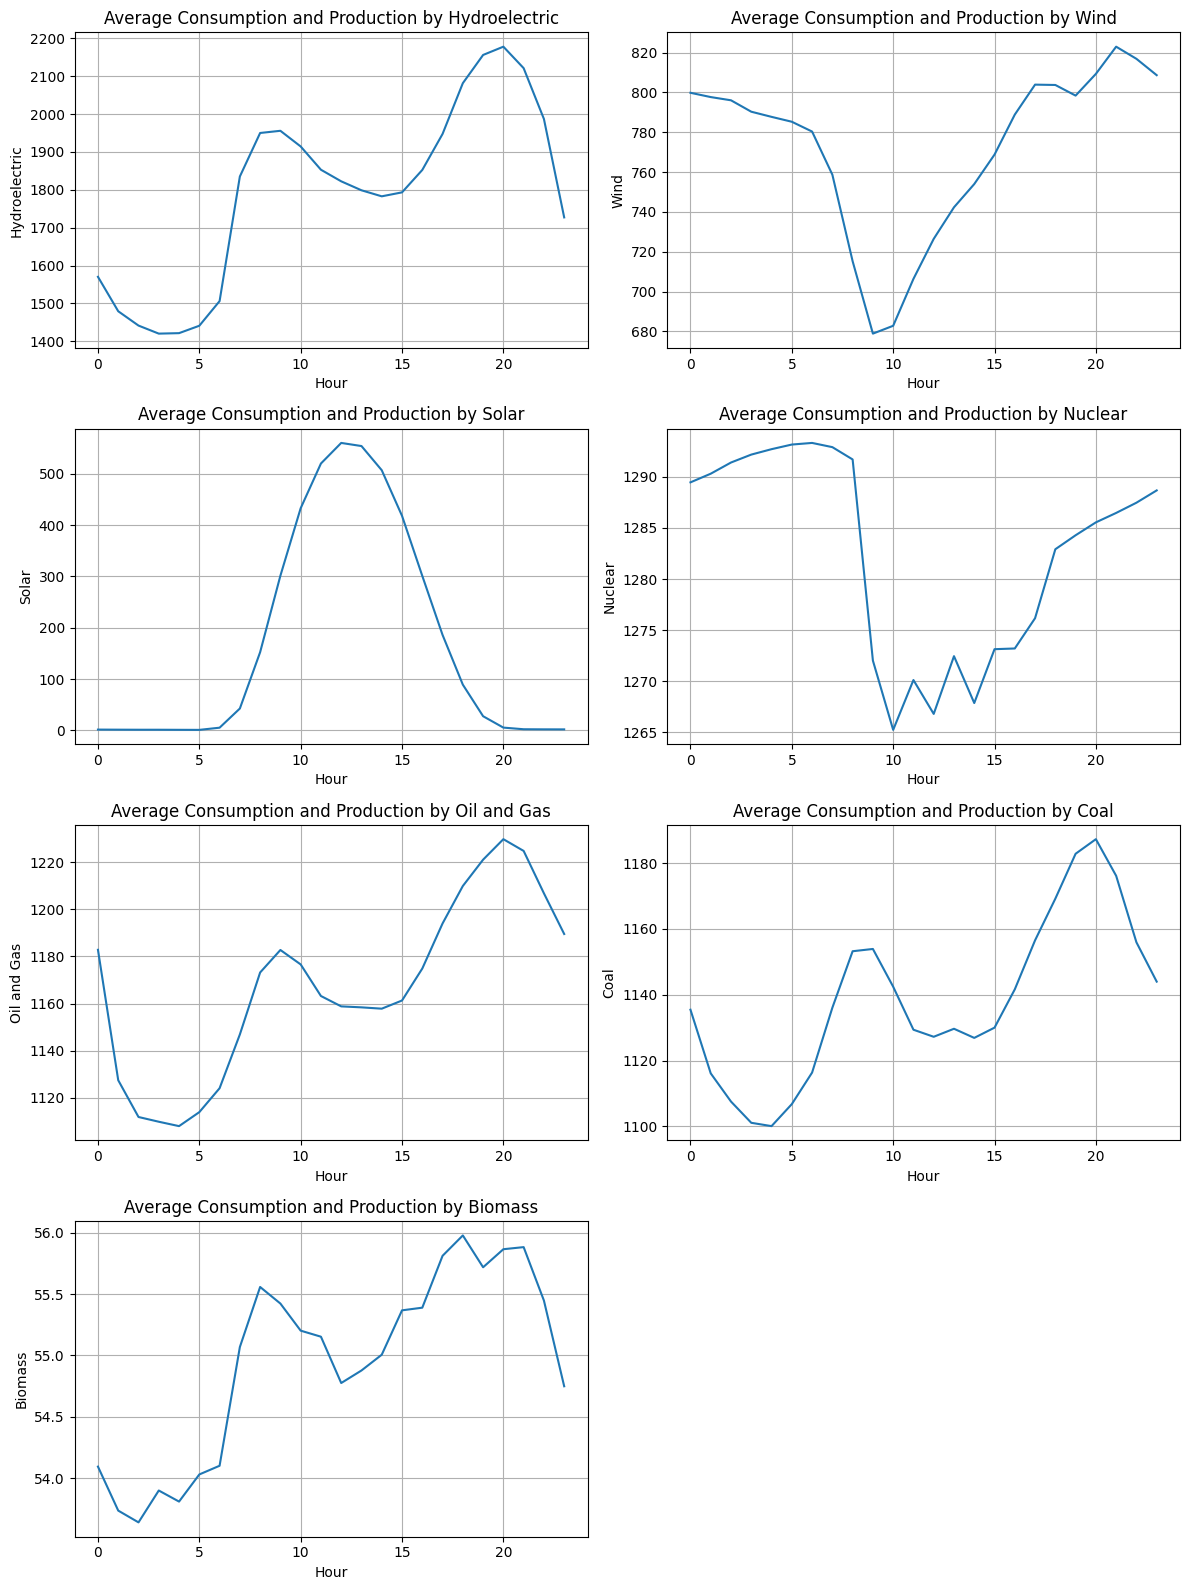

In [70]:
Source_columns = ['Hydroelectric', 'Wind', 'Solar', 'Nuclear', 'Oil and Gas', 'Coal', 'Biomass']

plt.figure(figsize=(12, 16))
for i, col in enumerate(Source_columns):
    plt.subplot(4, 2, i + 1)
    avg = df.groupby('Hour')[col].mean()
    sns.lineplot(data=avg)
    plt.title(f'Average Consumption and Production by {col}')
    plt.grid(True)

plt.tight_layout()
plt.show()